In [1]:
import debugpy; debugpy.listen(("0.0.0.0", 5678))

('0.0.0.0', 5678)

In [1]:
import sys
sys.path.append("CPE883-2025-02/models/")
sys.path.append("CPE883-2025-02/dataloaders/3W/")
sys.path.append("/3W")
path = "CPE883-2025-02/experiments/3W/timecaps/"

In [9]:
import importlib
importlib.reload(sys.modules['timeCaps.spectogram'])
from timeCaps.spectogram import spectrogram_temperature_scipy
import torch
import matplotlib.pyplot as plt


### Teste do Espectograma

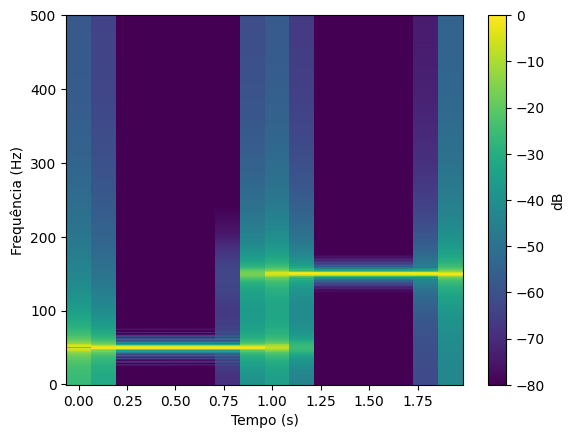

In [3]:
fs = 1000.0
Tsec = 2.0
t = torch.arange(int(fs*Tsec)) / fs
# Sinal muda de 50 Hz para 150 Hz após 1 s
x = torch.sin(2*torch.pi*50*t) * (t < 1.0) + torch.sin(2*torch.pi*150*t) * (t >= 1.0)

params = TorchSpecParams(
    fs=fs,
    n_fft=1024,
    win_length=512,
    hop_length=128,
    window="hann",
    scaling="spectrum",
    pre_emphasis=0.0,
    to_db=True,
    ref_power="max",
    top_db=80.0,
)

out = compute_spectrogram_torch(x, params, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))
# Ex.: out["db"].shape == (1,1,F,T)
# Para visualizar (opcional):
import matplotlib.pyplot as plt
plt.pcolormesh(out["t"].cpu(), out["f"].cpu(), out["db"][0,0].cpu(), shading="auto")
plt.xlabel("Tempo (s)"); plt.ylabel("Frequência (Hz)"); plt.colorbar(label="dB"); plt.show()

### Teste do Espectograma no DataLoader

In [3]:
#import importlib
#importlib.reload(sys.modules['loader'])
from loader import Loader3W

In [4]:
ld = Loader3W()
#ld.get_ids_from_wells_with_event_type([8])
#ld.extract_stats(['ABER-CKP', 'P-ANULAR', 'P-PDG','P-TPT','T-MON-CKP','T-PDG','T-TPT'])
#ld.save_stats(path+'stats.pkl')
ld.load_stats(path+'stats.pkl')

In [5]:
s=ld.preprocess()
s = s.send(None)  # Get first item from generator

In [11]:
s

,well,ABER-CKP,P-ANULAR,P-PDG,P-TPT,T-MON-CKP,T-PDG,T-TPT,state,ABER-CKP_relative_max,...,state-0,state-1,state-2,state-3,state-4,state-5,state-6,state-7,state-8,state-9
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-09-18 17:01:06,WELL-00027,NaN,NaN,NaN,0.719991,2.956074,NaN,0.999999,0,0.0,...,1,0,0,0,0,0,0,0,0,0
2023-09-18 17:01:07,WELL-00027,NaN,NaN,NaN,0.720057,2.956074,NaN,0.999999,0,0.0,...,1,0,0,0,0,0,0,0,0,0
2023-09-18 17:01:08,WELL-00027,NaN,NaN,NaN,0.720118,2.956074,NaN,0.999999,0,0.0,...,1,0,0,0,0,0,0,0,0,0
2023-09-18 17:01:09,WELL-00027,NaN,NaN,NaN,0.720183,2.956074,NaN,0.999999,0,0.0,...,1,0,0,0,0,0,0,0,0,0
2023-09-18 17:01:10,WELL-00027,NaN,NaN,NaN,0.720245,2.956074,NaN,0.999999,0,0.0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-26 14:01:21,WELL-00027,NaN,NaN,NaN,5.215945,-0.437424,NaN,0.999999,2,0.0,...,0,0,1,0,0,0,0,0,0,0
2023-09-26 14:01:22,WELL-00027,NaN,NaN,NaN,5.215677,-0.437424,NaN,0.999999,2,0.0,...,0,0,1,0,0,0,0,0,0,0
2023-09-26 14:01:23,WELL-00027,NaN,NaN,NaN,5.215405,-0.437424,NaN,0.999999,2,0.0,...,0,0,1,0,0,0,0,0,0,0


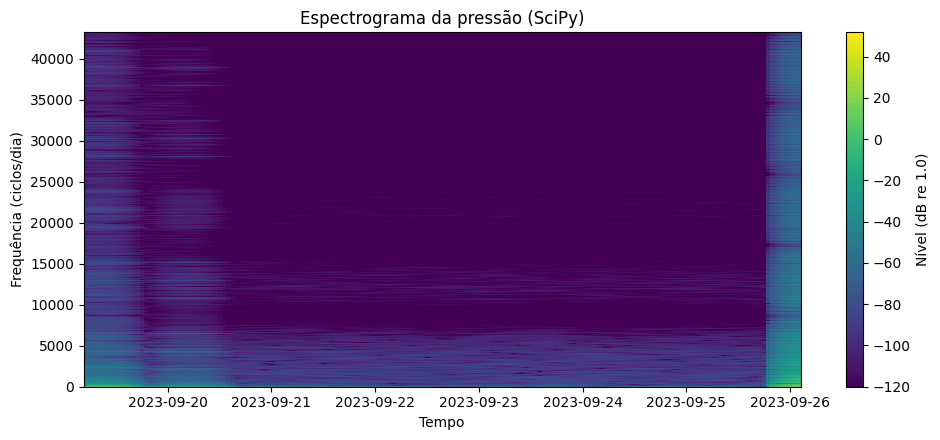

In [22]:
%matplotlib inline
f_cpd, t_dt, Z, meta = spectrogram_temperature_scipy(
    s['P-TPT'], win="1D", hop="1H", window="hann", scaling="density", to_db=True
)

plt.figure(figsize=(10, 4.5))
mesh = plt.pcolormesh(t_dt, f_cpd, Z, shading="auto")
plt.ylabel("Frequência (ciclos/dia)")
plt.xlabel("Tempo")
plt.title("Espectrograma da pressão (SciPy)")
cbar_label = "Nível (dB re 1.0)" if meta["to_db"] else "PSD (unidade²/Hz)"
plt.colorbar(mesh, label=cbar_label)
plt.tight_layout()
plt.show()

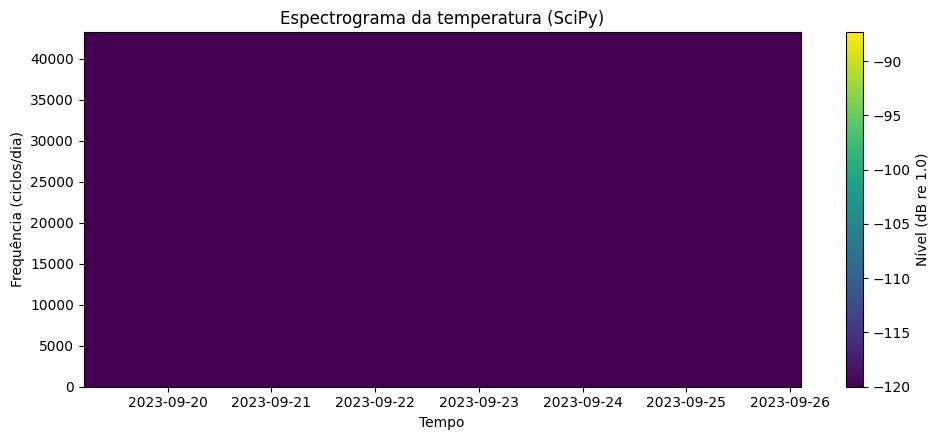

In [23]:
%matplotlib inline
f_cpd, t_dt, Z, meta = spectrogram_temperature_scipy(
    s['T-TPT'], win="1D", hop="1H", window="hann", scaling="density", to_db=True
)

plt.figure(figsize=(10, 4.5))
mesh = plt.pcolormesh(t_dt, f_cpd, Z, shading="auto")
plt.ylabel("Frequência (ciclos/dia)")
plt.xlabel("Tempo")
plt.title("Espectrograma da temperatura (SciPy)")
cbar_label = "Nível (dB re 1.0)" if meta["to_db"] else "PSD (unidade²/Hz)"
plt.colorbar(mesh, label=cbar_label)
plt.tight_layout()
plt.show()